# Punto 1 - MAP Threshold and Error Probability

Este notebook esta organizado por puntos y resuelve los cuatro enunciados del laboratorio:
- derivar y verificar el detector MAP escalar,
- estudiar el efecto de las probabilidades a priori,
- comparar el detector escalar con el detector matched-filter,
- comparar detectores analiticos MAP con clasificadores de machine learning.

El desarrollo se mantiene directo: modelo, derivacion necesaria, implementacion, tablas, graficas e interpretacion breve para cada punto.


## 1. Modelo y regla MAP

En el modelo binario tenemos:
- $H_0: Y = a_0 + \eta$
- $H_1: Y = a_1 + \eta$
donde $\eta \sim \mathcal{N}(0,\sigma_{\eta}^2)$ y $\pi_0 = P(H_0)$, $\pi_1 = P(H_1)$ con $\pi_0 + \pi_1 = 1$.

La regla MAP compara las probabilidades posteriores y conduce a un test de umbral:
$$\Lambda(y) = \frac{p(y\mid H_1)}{p(y\mid H_0)} \mathrel{\gtrless}_{H_0}^{H_1} \frac{\pi_0}{\pi_1}.$$

En el caso de densidades normales con igual varianza, el umbral se puede escribir en forma cerrada como $\gamma_{MAP}$.

In [1]:
# Importamos las librerías necesarias para el cálculo y la visualización
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Definimos los parámetros del problema
a0 = -1.0  # Amplitud asociada a H0
a1 = 1.0   # Amplitud asociada a H1
sigma_eta = 1.0  # Desviación estándar del ruido AWGN
pi0 = 0.5  # Probabilidad a priori de H0
pi1 = 0.5  # Probabilidad a priori de H1

# Verificamos que las probabilidades a priori sumen uno
if not np.isclose(pi0 + pi1, 1.0):
    raise ValueError("Las probabilidades a priori deben sumar uno.")

# Mostramos los parámetros para que el notebook sea autosuficiente
print(f"a0 = {a0}")
print(f"a1 = {a1}")
print(f"sigma_eta = {sigma_eta}")
print(f"pi0 = {pi0}")
print(f"pi1 = {pi1}")

a0 = -1.0
a1 = 1.0
sigma_eta = 1.0
pi0 = 0.5
pi1 = 0.5


## 2. Expresión analítica de $\gamma_{MAP}$

Para el caso gaussiano con igual varianza, las densidades condicionales son:
- $p(y\mid H_0) = \mathcal{N}(a_0, \sigma_{\eta}^2)$
- $p(y\mid H_1) = \mathcal{N}(a_1, \sigma_{\eta}^2)$

Al sustituir estas expresiones en la razón de verosimilitudes y simplificar, la comparación MAP se vuelve equivalente a comparar la observación $y$ con un umbral fijo.
El umbral analítico se obtiene a partir de la normalización y el logaritmo de la razon de probabilidades a priori.

Ese umbral tiene la forma:
$$\gamma_{MAP} = \frac{a_0 + a_1}{2} + \frac{\sigma_{\eta}^2}{a_1 - a_0} \ln\left(\frac{\pi_0}{\pi_1}\right).$$

Esta expresión muestra dos términos claros:
- Un término central $(a_0 + a_1)/2$, que es el punto medio entre los dos símbolos.
- Un desplazamiento adicional proporcional a $\ln(\pi_0 / \pi_1)$, que mueve el umbral hacia la hipotesis menos probable.

Cuando las probabilidades a priori son iguales ($\pi_0 = \pi_1$), el desplazamiento desaparece y el umbral es simplemente el punto medio entre $a_0$ y $a_1$.

Esta fórmula analítica es la referencia teórica que compararemos con el resultado numérico obtenido por búsqueda. Si la teoría es correcta, ambos valores deben coincidir o ser muy cercanos.


In [2]:
# Calculamos el umbral MAP analítico
gamma_map = (a0 + a1) / 2 + (sigma_eta**2 / (a1 - a0)) * np.log(pi0 / pi1)

# Mostramos el resultado del umbral
print(f"Umbral MAP analítico: gamma_map = {gamma_map:.6f}")

Umbral MAP analítico: gamma_map = 0.000000


## 3. Implementación del detector MAP y barrido de umbral

El detector MAP puede verse como un test de umbral sobre la variable observada $y$.
Para cada valor de umbral $\gamma$, la regla de decisión es:
- Si $y \geq \gamma$, se decide $H_1$.
- Si $y < \gamma$, se decide $H_0$.

Existen dos tipos de error en este test:
- Falsa alarma ($P_{FA}$): se decide $H_1$ cuando en realidad se transmitió $a_0$.
- Omisión o miss ($P_M$): se decide $H_0$ cuando en realidad se transmitió $a_1$.

Dado que bajo $H_0$ la variable $Y$ es normal con media $a_0$ y bajo $H_1$ es normal con media $a_1$, estas probabilidades se expresan mediante la función de distribución normal acumulada.

La probabilidad total de error combina ambas contribuciones con las probabilidades a priori:
$$P_e(\gamma) = \pi_0 P_{FA}(\gamma) + \pi_1 P_M(\gamma).$$

El objetivo del barrido de umbral es calcular $P_e(\gamma)$ para muchos valores de $\gamma$ y encontrar el valor que minimiza la tasa de error.

Después de este cálculo numérico, compararemos el umbral que minimiza $P_e$ con el umbral analítico $\gamma_{MAP}$ obtenido en la sección anterior.

In [3]:
# Definimos el intervalo de umbral para explorar
threshold_values = np.linspace(a0 - 4 * sigma_eta, a1 + 4 * sigma_eta, 1000)

# Calculamos las probabilidades condicionales de cada hipótesis
PFA = 1 - stats.norm.cdf(threshold_values, loc=a0, scale=sigma_eta)  # Falso alarma
PM = stats.norm.cdf(threshold_values, loc=a1, scale=sigma_eta)      # Miss

# Calculamos la probabilidad total de error usando las priors
Pe = pi0 * PFA + pi1 * PM

# Encontramos el umbral numérico con el menor Pe
index_opt = np.argmin(Pe)
gamma_numeric = threshold_values[index_opt]
Pe_numeric = Pe[index_opt]
PFA_numeric = PFA[index_opt]
PM_numeric = PM[index_opt]

# Mostramos los resultados numéricos
print(f"Umbral numérico óptimo: gamma_numeric = {gamma_numeric:.6f}")
print(f"P_e(gamma_numeric) = {Pe_numeric:.6f}")
print(f"P_FA(gamma_numeric) = {PFA_numeric:.6f}")
print(f"P_M(gamma_numeric) = {PM_numeric:.6f}")

Umbral numérico óptimo: gamma_numeric = -0.005005
P_e(gamma_numeric) = 0.158658
P_FA(gamma_numeric) = 0.159869
P_M(gamma_numeric) = 0.157447


## 4. Gráfico de $P_e(\gamma)$ y comparación

Graficaremos la probabilidad total de error en función del umbral y compararemos el umbral analítico con el umbral óptimo numérico.

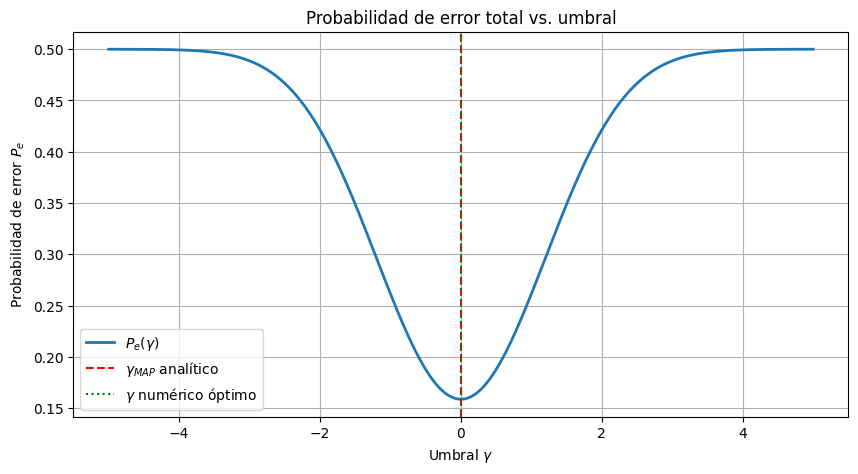

Resumen de resultados:
Umbral analítico gamma_map = 0.000000
Umbral numérico gamma_numeric = -0.005005
Pe(gamma_numeric) = 0.158658
PFA(gamma_numeric) = 0.159869
PM(gamma_numeric) = 0.157447


In [4]:
# Graficamos la función de error versus el umbral
plt.figure(figsize=(10, 5))
plt.plot(threshold_values, Pe, label=r"$P_e(\gamma)$", linewidth=2)
plt.axvline(gamma_map, color="red", linestyle="--", label=r"$\gamma_{MAP}$ analítico")
plt.axvline(gamma_numeric, color="green", linestyle=":", label=r"$\gamma$ numérico óptimo")
plt.xlabel(r"Umbral $\gamma$")
plt.ylabel(r"Probabilidad de error $P_e$")
plt.title("Probabilidad de error total vs. umbral")
plt.legend()
plt.grid(True)
plt.show()

# Mostramos una tabla resumida de resultados
print("Resumen de resultados:")
print(f"Umbral analítico gamma_map = {gamma_map:.6f}")
print(f"Umbral numérico gamma_numeric = {gamma_numeric:.6f}")
print(f"Pe(gamma_numeric) = {Pe_numeric:.6f}")
print(f"PFA(gamma_numeric) = {PFA_numeric:.6f}")
print(f"PM(gamma_numeric) = {PM_numeric:.6f}")

## Discusion del punto 1

El umbral analitico es $\gamma_{MAP}=0$ porque los simbolos son simetricos ($a_0=-1$, $a_1=1$) y las probabilidades a priori son iguales. El umbral numerico queda muy cercano a cero; la pequena diferencia se debe a que el barrido usa una grilla finita de valores de $\gamma$. Las probabilidades $P_{FA}$ y $P_M$ tambien son casi iguales, como se espera por simetria.


## 5. Punto 2: efecto de las probabilidades a priori

En este punto usamos la misma configuración de detección binaria con ruido AWGN, pero variamos las probabilidades a priori de la hipótesis $H_1$.
Para cada valor de $\pi_1 \in \{0.1,0.3,0.5,0.7,0.9\}$ calculamos el umbral MAP y evaluamos las probabilidades de error de falsa alarma y omisión.

La expresión analítica del umbral MAP es:
$$\gamma_{MAP} = \frac{a_0 + a_1}{2} + \frac{\sigma_{\eta}^2}{a_1 - a_0} \ln\left(\frac{\pi_0}{\pi_1}\right)$$

Este umbral se desplaza hacia la hipótesis menos probable porque el término logarítmico cambia de signo según cuál prior sea mayor.
Con priors muy desbalanceadas y ruido suficiente, el umbral puede incluso salir del intervalo $[a_0, a_1]$.

A continuación calculamos y graficamos:
- $\gamma_{MAP}$ en función de $\pi_1$.
- $P_{FA}$, $P_M$ y $P_e$ en el umbral MAP.



Tabla de resultados para diferentes valores de pi1:
pi1    gamma_MAP      P_FA        P_M         P_e
0.1   1.098612   0.017926   0.539277   0.070061
0.3   0.423649   0.077274   0.282189   0.138749
0.5   0.000000   0.158655   0.158655   0.158655
0.7   -0.423649   0.282189   0.077274   0.138749
0.9   -1.098612   0.539277   0.017926   0.070061


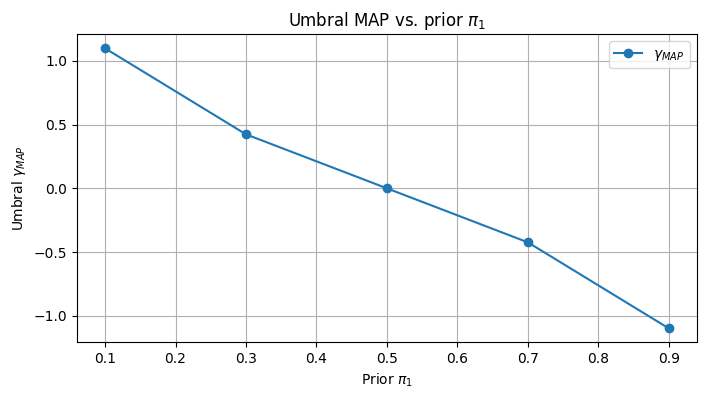

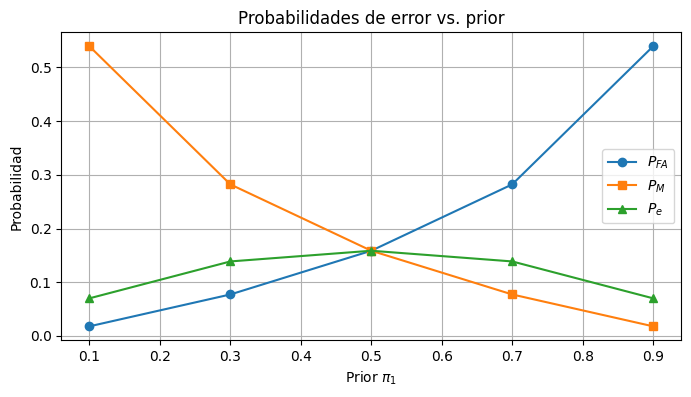

In [5]:
# Punto 2: desarrollo de BinDetection_Lab_2.pdf
# Calculamos el umbral MAP y las probabilidades de error para varios valores de pi1.
pi1_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
pi0_values = 1 - pi1_values

gamma_map_values = (a0 + a1) / 2 + (sigma_eta**2 / (a1 - a0)) * np.log(pi0_values / pi1_values)

PFA_values = 1 - stats.norm.cdf(gamma_map_values, loc=a0, scale=sigma_eta)
PM_values = stats.norm.cdf(gamma_map_values, loc=a1, scale=sigma_eta)
Pe_values = pi0_values * PFA_values + pi1_values * PM_values

print("Tabla de resultados para diferentes valores de pi1:")
print("pi1    gamma_MAP      P_FA        P_M         P_e")
for pi1, gamma_map_i, PFA_i, PM_i, Pe_i in zip(pi1_values, gamma_map_values, PFA_values, PM_values, Pe_values):
    print(f"{pi1:0.1f}   {gamma_map_i:0.6f}   {PFA_i:0.6f}   {PM_i:0.6f}   {Pe_i:0.6f}")

plt.figure(figsize=(8, 4))
plt.plot(pi1_values, gamma_map_values, marker="o", linestyle="-", label=r"$\gamma_{MAP}$")
plt.xlabel(r"Prior $\pi_1$")
plt.ylabel(r"Umbral $\gamma_{MAP}$")
plt.title(r"Umbral MAP vs. prior $\pi_1$")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(pi1_values, PFA_values, marker="o", label=r"$P_{FA}$")
plt.plot(pi1_values, PM_values, marker="s", label=r"$P_{M}$")
plt.plot(pi1_values, Pe_values, marker="^", label=r"$P_{e}$")
plt.xlabel(r"Prior $\pi_1$")
plt.ylabel("Probabilidad")
plt.title("Probabilidades de error vs. prior")
plt.grid(True)
plt.legend()
plt.show()


## Interpretacion del punto 2

Cuando $\pi_1$ aumenta, decidir $H_1$ se vuelve menos costoso y el umbral baja, acercandose a $H_0$, que es la hipotesis menos probable. Por eso $P_{FA}$ aumenta y $P_M$ disminuye. Con ruido alto o priors muy desbalanceadas, el termino logaritmico puede dominar al punto medio y llevar $\gamma_{MAP}$ fuera del intervalo $[a_0,a_1]$.


## Punto 3 - Detector escalar vs. matched-filter

Para cada simbolo rectangular de longitud $L$ se observa
$$r_k[n] = a_k + \eta_k[n], \quad n=0,1,\ldots,L-1.$$

El detector escalar usa una sola muestra, $Y_k=r_k[0]$, por lo que su varianza de ruido sigue siendo $\sigma_{\eta}^2$. En cambio, el matched-filter implementado como integrate-and-dump usa
$$Z_k = rac{1}{L}\sum_{n=0}^{L-1} r_k[n] = a_k + rac{1}{L}\sum_{n=0}^{L-1}\eta_k[n].$$

Como las muestras de ruido son independientes,
$$\operatorname{Var}(Z_k\mid H_i)=\operatorname{Var}\left(rac{1}{L}\sum_{n=0}^{L-1}\eta_k[n]ight)=rac{\sigma_{\eta}^2}{L}.$$

Por eso el promediado reduce la varianza efectiva del ruido y produce una ganancia teorica
$$G_{MF}=10\log_{10}(L)\;	ext{dB}.$$

Con priors iguales y simbolos simetricos se usa el mismo umbral de decision, $(a_0+a_1)/2$.


L  error_scalar  error_matched  var(Z)  G_MF[dB]
 1  0.15751       0.15751       1.00000   0.00
 2  0.15823       0.07853       0.50000   3.01
 4  0.15874       0.02292       0.25000   6.02
 8  0.15897       0.00213       0.12500   9.03
16  0.15871       0.00002       0.06250   12.04
32  0.15844       0.00000       0.03125   15.05
64  0.15881       0.00000       0.01562   18.06


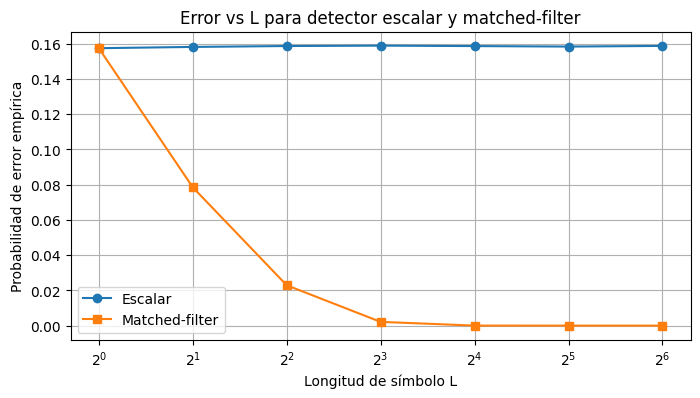

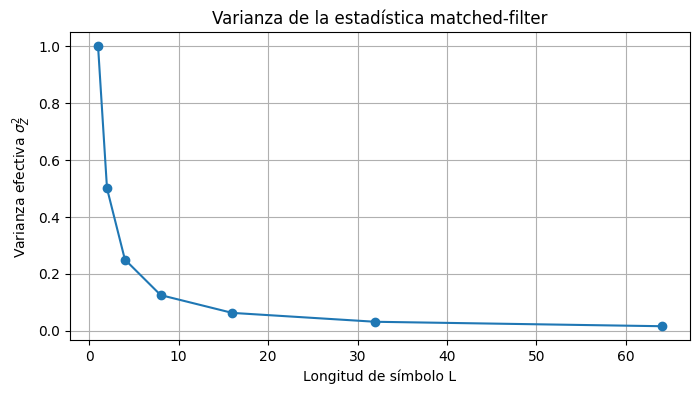

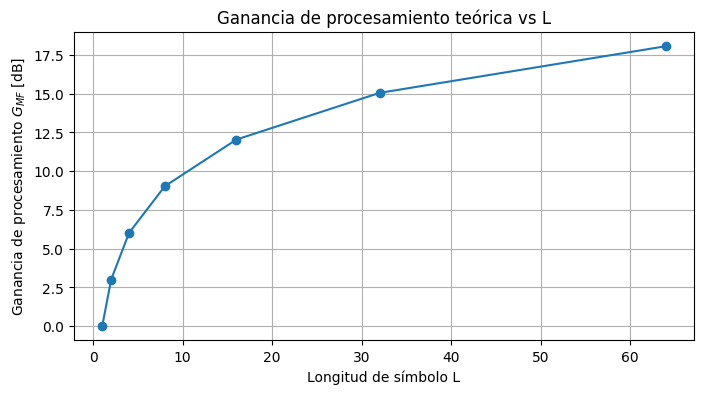

In [6]:
# Punto 3: detector escalar vs matched-filter
L_values = np.array([1, 2, 4, 8, 16, 32, 64])
Nsim = 100000
rng_p3 = np.random.default_rng(2026)
threshold = (a0 + a1) / 2

error_scalar = []
error_matched = []
variance_Z = []
processing_gain_db = []

for L in L_values:
    # Simulación de símbolos iguales para H0 y H1 con probabilidades 0.5
    symbols = np.concatenate([np.full(Nsim, a0), np.full(Nsim, a1)])
    noise = rng_p3.normal(0, sigma_eta, size=(2 * Nsim, L))
    r = symbols[:, None] + noise

    Y = r[:, 0]
    Z = r.mean(axis=1)

    decisions_scalar = np.where(Y >= threshold, a1, a0)
    decisions_matched = np.where(Z >= threshold, a1, a0)

    error_scalar.append(np.mean(decisions_scalar != symbols))
    error_matched.append(np.mean(decisions_matched != symbols))
    variance_Z.append(sigma_eta**2 / L)
    processing_gain_db.append(10 * np.log10(L))

error_scalar = np.array(error_scalar)
error_matched = np.array(error_matched)
variance_Z = np.array(variance_Z)
processing_gain_db = np.array(processing_gain_db)

print("L  error_scalar  error_matched  var(Z)  G_MF[dB]")
for L, es, em, vz, gm in zip(L_values, error_scalar, error_matched, variance_Z, processing_gain_db):
    print(f"{L:2d}  {es:0.5f}       {em:0.5f}       {vz:0.5f}   {gm:0.2f}")

plt.figure(figsize=(8, 4))
plt.plot(L_values, error_scalar, marker="o", label="Escalar")
plt.plot(L_values, error_matched, marker="s", label="Matched-filter")
plt.xscale("log", base=2)
plt.xlabel("Longitud de símbolo L")
plt.ylabel("Probabilidad de error empírica")
plt.title("Error vs L para detector escalar y matched-filter")
plt.grid(True, which="both")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(L_values, variance_Z, marker="o")
plt.xlabel("Longitud de símbolo L")
plt.ylabel(r"Varianza efectiva $\sigma_Z^2$")
plt.title("Varianza de la estadística matched-filter")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(L_values, processing_gain_db, marker="o")
plt.xlabel("Longitud de símbolo L")
plt.ylabel(r"Ganancia de procesamiento $G_{MF}$ [dB]")
plt.title("Ganancia de procesamiento teórica vs L")
plt.grid(True)
plt.show()

## Discusion del punto 3

El detector escalar mantiene una probabilidad de error casi constante al variar $L$ porque solo usa una muestra del bloque. El matched-filter si mejora con $L$ porque promedia muestras independientes de ruido; al bajar la varianza efectiva a $\sigma_{\eta}^2/L$, las distribuciones condicionales se separan mas en unidades de desviacion estandar. Por eso su error cae rapidamente mientras la ganancia $10\log_{10}(L)$ crece de forma logaritmica.


## 6. Punto 4: MAP vs Machine Learning (BinDetection_Lab_4.pdf)

En este punto comparamos:
- el detector MAP escalar usando una sola muestra por símbolo.
- el detector MAP matched-filter usando la estadística $Z_k = \frac{1}{L} \sum_{n=0}^{L-1} r_k[n]$.
- un clasificador de regresión logística entrenado con la estadística matched-filter.
- un perceptrón multicapa (MLP) entrenado con la estadística matched-filter.
- un perceptrón multicapa entrenado con el bloque completo $r_k$.

Generamos un conjunto de datos simulado con etiquetas conocidas, lo separamos en entrenamiento, validación y prueba, y calculamos las métricas estándar $P_e$, $P_{FA}$, $P_M$ y $P_D$.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# Parametros del experimento
L = 8
N_total = 30000
rng = np.random.default_rng(2026)

# Generamos el dataset simulado: cada fila es un bloque recibido r_k y cada etiqueta indica H0/H1.
labels = rng.choice([0, 1], size=N_total, p=[0.5, 0.5])
symbols = np.where(labels == 0, a0, a1)
noise = rng.normal(0, sigma_eta, size=(N_total, L))
r_blocks = symbols[:, None] + noise

# Particiones: entrenamiento 60%, validacion 20%, prueba 20%.
# La validacion queda disponible para ajustar hiperparametros; aqui usamos hiperparametros fijos.
X_train_full, X_temp_full, y_train, y_temp = train_test_split(
    r_blocks, labels, test_size=0.4, stratify=labels, random_state=2026
)
X_val_full, X_test_full, y_val, y_test = train_test_split(
    X_temp_full, y_temp, test_size=0.5, stratify=y_temp, random_state=2026
)

Z_train = X_train_full.mean(axis=1).reshape(-1, 1)
Z_val = X_val_full.mean(axis=1).reshape(-1, 1)
Z_test = X_test_full.mean(axis=1).reshape(-1, 1)
X_test_scalar = X_test_full[:, 0].reshape(-1, 1)

def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    PFA = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    PM = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    PD = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    Pe = (fp + fn) / (fp + fn + tp + tn)
    return PFA, PM, PD, Pe

# Detectores analiticos MAP con priors iguales.
threshold = (a0 + a1) / 2
y_pred_scalar = np.where(X_test_scalar[:, 0] >= threshold, 1, 0)
y_pred_matched = np.where(Z_test[:, 0] >= threshold, 1, 0)

# Regresion logistica con Z_k.
logreg = LogisticRegression(random_state=2026, max_iter=1000)
logreg.fit(Z_train, y_train)
y_pred_logreg = logreg.predict(Z_test)

# MLP con Z_k.
mlp_z = MLPClassifier(
    hidden_layer_sizes=(16,), activation="relu", solver="adam", max_iter=500, random_state=2026
)
mlp_z.fit(Z_train, y_train)
y_pred_mlp_z = mlp_z.predict(Z_test)

# MLP con todo el bloque r_k.
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_val_full_scaled = scaler.transform(X_val_full)
X_test_full_scaled = scaler.transform(X_test_full)
mlp_full = MLPClassifier(
    hidden_layer_sizes=(32, 16), activation="relu", solver="adam", max_iter=500, random_state=2026
)
mlp_full.fit(X_train_full_scaled, y_train)
y_pred_mlp_full = mlp_full.predict(X_test_full_scaled)

results = {}
for name, input_name, y_pred in [
    ("Scalar MAP", "One sample", y_pred_scalar),
    ("Matched-filter MAP", "Z_k", y_pred_matched),
    ("Logistic regression", "Z_k", y_pred_logreg),
    ("MLP", "Z_k", y_pred_mlp_z),
    ("MLP", "r_k", y_pred_mlp_full),
]:
    PFA, PM, PD, Pe = compute_metrics(y_test, y_pred)
    results[(name, input_name)] = {
        "PFA": PFA,
        "PM": PM,
        "PD": PD,
        "Pe": Pe,
        "cm": confusion_matrix(y_test, y_pred),
    }

print(f"Dataset: N={N_total}, L={L}, train={len(y_train)}, validation={len(y_val)}, test={len(y_test)}")
print("Resultados en el conjunto de prueba:")
print("{:<24}{:<14}{:>8}{:>8}{:>8}{:>8}".format("Detector", "Input", "P_e", "P_FA", "P_M", "P_D"))
for (name, input_name), info in results.items():
    print("{:<24}{:<14}{:>8.5f}{:>8.5f}{:>8.5f}{:>8.5f}".format(
        name, input_name, info["Pe"], info["PFA"], info["PM"], info["PD"]
    ))

print("\nMatrices de confusion [filas: etiqueta real 0/1, columnas: prediccion 0/1]:")
for (name, input_name), info in results.items():
    print(f"{name} ({input_name})")
    print(info["cm"])
    print()


Dataset: N=30000, L=8, train=18000, validation=6000, test=6000
Resultados en el conjunto de prueba:
Detector                Input              P_e    P_FA     P_M     P_D
Scalar MAP              One sample     0.14783 0.14983 0.14582 0.85418
Matched-filter MAP      Z_k            0.00267 0.00266 0.00268 0.99732
Logistic regression     Z_k            0.00267 0.00266 0.00268 0.99732
MLP                     Z_k            0.00283 0.00266 0.00301 0.99699
MLP                     r_k            0.00367 0.00365 0.00368 0.99632

Matrices de confusion [filas: etiqueta real 0/1, columnas: prediccion 0/1]:
Scalar MAP (One sample)
[[2559  451]
 [ 436 2554]]

Matched-filter MAP (Z_k)
[[3002    8]
 [   8 2982]]

Logistic regression (Z_k)
[[3002    8]
 [   8 2982]]

MLP (Z_k)
[[3002    8]
 [   9 2981]]

MLP (r_k)
[[2999   11]
 [  11 2979]]



## Discusion del punto 4

Cuando los datos simulados siguen el mismo modelo gaussiano usado para derivar el MAP, los clasificadores supervisados tienden a reproducir la frontera analitica en vez de superarla. La regresion logistica con $Z_k$ aprende un umbral lineal equivalente al matched-filter MAP. El MLP con $Z_k$ no agrega informacion nueva, y el MLP con el bloque completo solo puede igualar aproximadamente al detector que ya usa la estadistica suficiente para este modelo. El aprendizaje supervisado podria mejorar si el modelo estadistico asumido fuera incorrecto, si el ruido no fuera gaussiano, o si existieran no linealidades no contempladas por el detector analitico.
